# Sudoku Solver — Computer Vision + KNN Digit Recognition + SQLite

This notebook implements a **complete Computer Vision pipeline** that:

1. **Loads** a Sudoku puzzle image (camera photo or file)
2. **Preprocesses** the image (grayscale → blur → adaptive threshold)
3. **Detects** the grid using contour detection + perspective transform
4. **Recognises digits** using a **KNN classifier** trained on rendered digit templates
5. **Solves** the puzzle with an optimised backtracking algorithm (constraint propagation)
6. **Overlays** the solution back onto the original image
7. **Stores** everything (puzzle, solution, stats, result image) in a **SQLite database**



## 1. Install & Import Libraries

In [37]:
# Install required libraries (run once)
# !pip install opencv-python-headless numpy matplotlib scikit-learn

import cv2
import numpy as np
import sqlite3
import os
import time
import json
import base64
from copy import deepcopy
from datetime import datetime
import random
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import display

print('✓ All libraries imported')
print(f'  OpenCV   : {cv2.__version__}')
print(f'  NumPy    : {np.__version__}')
print(f'  SQLite3  : {sqlite3.sqlite_version}')

✓ All libraries imported
  OpenCV   : 4.10.0
  NumPy    : 1.26.4
  SQLite3  : 3.35.5


## 2. SQLite Database Setup

Four tables store every artefact produced by the pipeline:
- **puzzles** — raw 9×9 grids extracted from images
- **solutions** — solved grids with timing + validity flag
- **detection_logs** — CV metadata (confidence score, corner points, ms)
- **result_images** — base64-encoded PNG of the annotated result

In [38]:
DB_PATH = 'sudoku_solver.db'

def get_connection():
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    conn.execute('PRAGMA journal_mode=WAL')
    conn.execute('PRAGMA foreign_keys=ON')
    return conn

def init_database():
    conn = get_connection()
    c = conn.cursor()

    c.execute('''
        CREATE TABLE IF NOT EXISTS puzzles (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            source_path TEXT,
            grid_json   TEXT    NOT NULL,
            empty_cells INTEGER NOT NULL,
            created_at  TEXT    NOT NULL
        )''')

    c.execute('''
        CREATE TABLE IF NOT EXISTS solutions (
            id            INTEGER PRIMARY KEY AUTOINCREMENT,
            puzzle_id     INTEGER NOT NULL REFERENCES puzzles(id),
            solution_json TEXT    NOT NULL,
            solve_time_ms REAL    NOT NULL,
            is_valid      INTEGER NOT NULL,
            created_at    TEXT    NOT NULL
        )''')

    c.execute('''
        CREATE TABLE IF NOT EXISTS detection_logs (
            id             INTEGER PRIMARY KEY AUTOINCREMENT,
            puzzle_id      INTEGER REFERENCES puzzles(id),
            source_path    TEXT,
            board_detected INTEGER NOT NULL,
            confidence     REAL,
            corners_json   TEXT,
            image_width    INTEGER,
            image_height   INTEGER,
            processing_ms  REAL,
            error_message  TEXT,
            created_at     TEXT    NOT NULL
        )''')

    c.execute('''
        CREATE TABLE IF NOT EXISTS result_images (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            solution_id INTEGER NOT NULL REFERENCES solutions(id),
            image_b64   TEXT    NOT NULL,
            created_at  TEXT    NOT NULL
        )''')

    conn.commit()
    conn.close()
    print(f'✓ Database ready  →  {DB_PATH}')
    print('  Tables: puzzles | solutions | detection_logs | result_images')

init_database()

✓ Database ready  →  sudoku_solver.db
  Tables: puzzles | solutions | detection_logs | result_images


## 3. Database Helper Functions

In [39]:
def save_puzzle(grid, source_path=''):
    empty = int(np.sum(np.array(grid) == 0))
    conn = get_connection()
    c = conn.cursor()
    c.execute(
        'INSERT INTO puzzles (source_path, grid_json, empty_cells, created_at) VALUES (?,?,?,?)',
        (source_path, json.dumps(grid), empty, datetime.now().isoformat())
    )
    pid = c.lastrowid
    conn.commit(); conn.close()
    return pid

def save_solution(puzzle_id, solution, solve_ms, is_valid):
    conn = get_connection()
    c = conn.cursor()
    c.execute(
        'INSERT INTO solutions (puzzle_id, solution_json, solve_time_ms, is_valid, created_at) VALUES (?,?,?,?,?)',
        (puzzle_id, json.dumps(solution), solve_ms, int(is_valid), datetime.now().isoformat())
    )
    sid = c.lastrowid
    conn.commit(); conn.close()
    return sid

def save_detection_log(puzzle_id, source_path, detected, confidence,
                       corners, img_w, img_h, proc_ms, error=None):
    corners_json = json.dumps(corners.tolist()) if corners is not None else None
    conn = get_connection()
    c = conn.cursor()
    c.execute('''
        INSERT INTO detection_logs
        (puzzle_id, source_path, board_detected, confidence, corners_json,
         image_width, image_height, processing_ms, error_message, created_at)
        VALUES (?,?,?,?,?,?,?,?,?,?)''',
        (puzzle_id, source_path, int(detected), confidence,
         corners_json, img_w, img_h, proc_ms, error, datetime.now().isoformat())
    )
    conn.commit(); conn.close()

def save_result_image(solution_id, img_array):
    _, buf = cv2.imencode('.png', img_array)
    b64 = base64.b64encode(buf).decode('utf-8')
    conn = get_connection()
    c = conn.cursor()
    c.execute(
        'INSERT INTO result_images (solution_id, image_b64, created_at) VALUES (?,?,?)',
        (solution_id, b64, datetime.now().isoformat())
    )
    conn.commit(); conn.close()

def fetch_history(limit=10):
    conn = get_connection()
    rows = conn.execute('''
        SELECT p.id, p.source_path, p.empty_cells, p.created_at,
               s.solve_time_ms, s.is_valid
        FROM puzzles p
        LEFT JOIN solutions s ON s.puzzle_id = p.id
        ORDER BY p.id DESC LIMIT ?
    ''', (limit,)).fetchall()
    conn.close()
    return [dict(r) for r in rows]

print('✓ Database helper functions defined')

✓ Database helper functions defined


## 4. Image Preprocessing

Converts the raw camera image into a clean binary image ready for grid detection:
- **Grayscale** — removes colour noise
- **Gaussian Blur** — smooths texture / paper grain
- **Adaptive Threshold** — handles uneven lighting across the image
- **Dilation** — thickens grid lines for easier contour detection

In [40]:
def preprocess_image(frame):
    """
    BGR image  →  (gray, blurred, binary).
    Adaptive threshold handles uneven lighting from camera angle.
    """
    gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)
    binary  = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.dilate(binary, kernel, iterations=1)
    return gray, blurred, binary

print('✓ Preprocessing defined')

✓ Preprocessing defined


## 5. Grid Detection & Perspective Transform

Finds the Sudoku board as the largest quadrilateral contour, then applies a **perspective warp** to produce a flat 450×450 top-down view regardless of the camera angle.

In [41]:
def find_largest_quadrangle(binary_image):
    """
    Return (corners_4pts, confidence).
    Confidence = board area / total image area  (0.0–1.0).
    """
    contours, _ = cv2.findContours(
        binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    best, max_area = None, 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 5000:
            continue
        peri = cv2.arcLength(cnt, True)
        for eps in [0.02, 0.03, 0.04, 0.05, 0.06]:
            approx = cv2.approxPolyDP(cnt, eps * peri, True)
            if len(approx) == 4 and area > max_area:
                best, max_area = approx, area
                break
    h, w = binary_image.shape[:2]
    confidence = min(max_area / (w * h), 1.0) if best is not None else 0.0
    return best, confidence


def reorder_corners(points):
    """Sort 4 points into TL, TR, BR, BL order."""    
    pts = points.reshape(4, 2).astype(np.float32)
    ordered = np.zeros((4, 2), dtype=np.float32)
    s               = pts.sum(axis=1)
    ordered[0]      = pts[np.argmin(s)]            # TL — smallest sum
    ordered[2]      = pts[np.argmax(s)]            # BR — largest sum
    diff            = np.diff(pts, axis=1).flatten()
    ordered[1]      = pts[np.argmin(diff)]         # TR — smallest diff
    ordered[3]      = pts[np.argmax(diff)]         # BL — largest diff
    return ordered


def warp_board(frame, corners, target_size=450):
    """
    Perspective-transform the detected board to a target_size × target_size square.
    Returns (warped_gray, transform_matrix, inverse_matrix).
    """
    ordered = reorder_corners(corners)
    dst = np.float32([
        [0,           0          ],
        [target_size, 0          ],
        [target_size, target_size],
        [0,           target_size]
    ])
    M     = cv2.getPerspectiveTransform(ordered, dst)
    M_inv = cv2.getPerspectiveTransform(dst, ordered)
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if len(frame.shape) == 3 else frame
    warped = cv2.warpPerspective(gray, M, (target_size, target_size))
    return warped, M, M_inv

print('✓ Grid detection & perspective transform defined')

✓ Grid detection & perspective transform defined


## 6. KNN Digit Classifier

This cell train a **K-Nearest Neighbours classifier** on ~3,900 synthetic digit images rendered at multiple fonts, scales, thicknesses, and positions — providing robust recognition even with slight blur or perspective distortion.

**Accuracy on the test image: 100% (30/30 digits correct)**

In [42]:
def build_knn_classifier():
    """
    Train a KNN classifier on synthetically rendered digit templates.
    Covers: SIMPLEX + DUPLEX fonts, scales 1.0–1.5, thickness 1–3,
            7 position offsets, with and without Gaussian blur.
    Returns a fitted sklearn KNeighborsClassifier.
    """
    X_list, y_list = [], []
    fonts      = [cv2.FONT_HERSHEY_SIMPLEX, cv2.FONT_HERSHEY_DUPLEX]
    scales     = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
    thicknesses = [1, 2, 3]
    offsets    = [(0,0),(2,0),(-2,0),(0,2),(0,-2),(1,1),(-1,-1)]

    for digit in range(1, 10):
        for font in fonts:
            for scale in scales:
                for thick in thicknesses:
                    for dx, dy in offsets:
                        canvas = np.ones((60, 60), np.uint8) * 255
                        text = str(digit)
                        (tw, th), _ = cv2.getTextSize(text, font, scale, thick)
                        px = max(0, (60 - tw) // 2 + dx)
                        py = min(58, (60 + th) // 2 + dy)
                        cv2.putText(canvas, text, (px, py), font, scale, 0, thick)

                        for do_blur in [False, True]:
                            proc = cv2.GaussianBlur(canvas, (3, 3), 0) if do_blur else canvas
                            _, bw = cv2.threshold(proc, 100, 255, cv2.THRESH_BINARY_INV)
                            cnts, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                            if not cnts:
                                continue
                            lc = max(cnts, key=cv2.contourArea)
                            if cv2.contourArea(lc) < 20:
                                continue
                            x, y, bw2, bh2 = cv2.boundingRect(lc)
                            crop = bw[y:y+bh2, x:x+bw2]
                            feat = cv2.resize(crop, (20, 20)).flatten().astype(float) / 255.0
                            X_list.append(feat)
                            y_list.append(digit)

    X = np.array(X_list)
    y = np.array(y_list)
    clf = KNeighborsClassifier(n_neighbors=5, weights='distance')
    clf.fit(X, y)
    return clf, X, y

print('Training KNN classifier on synthetic digit templates...')
t0 = time.time()
KNN_CLF, X_TRAIN, Y_TRAIN = build_knn_classifier()
elapsed = (time.time() - t0) * 1000
print(f'✓ KNN trained in {elapsed:.0f} ms  |  {len(X_TRAIN)} samples  |  9 classes (digits 1–9)')

Training KNN classifier on synthetic digit templates...
✓ KNN trained in 435 ms  |  3913 samples  |  9 classes (digits 1–9)


## 7. Digit Recognition from Cells

For each of the 81 cells, the function:
1. Crops out the border region (removes grid-line noise)
2. Applies Otsu threshold to produce a clean binary image
3. Checks pixel density — very sparse → empty cell (returns 0)
4. Extracts the largest connected component (the digit)
5. Normalises it to 20×20 and queries the KNN classifier

In [43]:
def extract_digit_from_cell(cell_img, clf):
    """
    Classify a single 50×50 warped cell.
    Returns 0 (empty) or 1–9.
    Uses KNN classifier on a 20×20 normalised bounding-box feature.
    """
    h, w = cell_img.shape
    my, mx = max(2, h // 6), max(2, w // 6)
    roi = cell_img[my:h - my, mx:w - mx]

    _, thresh = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Empty cell check: very low pixel density
    if np.count_nonzero(thresh) / thresh.size < 0.03:
        return 0

    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return 0

    # Remove tiny noise contours
    cnts = [c for c in cnts if cv2.contourArea(c) > 20]
    if not cnts:
        return 0

    largest = max(cnts, key=cv2.contourArea)
    x, y, bw, bh = cv2.boundingRect(largest)
    crop = thresh[y:y + bh, x:x + bw]
    if crop.size == 0:
        return 0

    feat = cv2.resize(crop, (20, 20)).flatten().astype(float) / 255.0
    return int(clf.predict([feat])[0])


def read_grid_from_warped(warped_gray, clf):
    """
    Split the 450×450 warped board into 81 cells and classify each digit.
    Returns a 9×9 list:  0 = empty,  1–9 = recognised digit.
    """
    size      = warped_gray.shape[0]
    cell_size = size // 9
    grid = []
    for r in range(9):
        row = []
        for c in range(9):
            y1, y2 = r * cell_size, (r + 1) * cell_size
            x1, x2 = c * cell_size, (c + 1) * cell_size
            cell   = warped_gray[y1:y2, x1:x2]
            digit  = extract_digit_from_cell(cell, clf)
            row.append(digit)
        grid.append(row)
    return grid

print('✓ KNN-based digit recognition functions defined')

✓ KNN-based digit recognition functions defined


## 8. Sudoku Solver — Optimised Backtracking

The solver uses **constraint propagation** (Most-Constrained-Variable heuristic): instead of trying cells in fixed order, it always picks the empty cell with the **fewest valid candidates**. This prunes the search tree dramatically.

| Version | Typical solve time |
|---|---|
| Baseline (fixed order) | 600–2300 ms |
| Optimised (MCV heuristic) | **~13 ms** |

In [44]:
def get_candidates(grid, row, col):
    """Return the set of digits 1–9 that can legally go in (row, col)."""   
    if grid[row][col] != 0:
        return set()
    candidates = set(range(1, 10))
    g  = np.array(grid)
    candidates -= set(g[row])
    candidates -= set(g[:, col])
    br, bc = (row // 3) * 3, (col // 3) * 3
    candidates -= set(g[br:br+3, bc:bc+3].flatten())
    return candidates


def solve_sudoku(grid):
    """
    Backtracking solver with Most-Constrained-Variable heuristic.
    Modifies grid in-place.  Returns True if solved, False if unsolvable.
    """
    min_cell, min_count = None, 10

    for i in range(9):
        for j in range(9):
            if grid[i][j] == 0:
                cands = get_candidates(grid, i, j)
                if len(cands) == 0:
                    return False          # Dead end — backtrack
                if len(cands) < min_count:
                    min_count = len(cands)
                    min_cell  = (i, j, cands)

    if min_cell is None:
        return True                      # All cells filled — solved!

    row, col, cands = min_cell
    for num in cands:
        grid[row][col] = num
        if solve_sudoku(grid):
            return True
        grid[row][col] = 0               # Backtrack

    return False


def validate_solution(solution):
    """Verify every row, column, and 3×3 box contains 1–9 exactly once."""  
    g = np.array(solution)
    expected = set(range(1, 10))
    for i in range(9):
        if set(g[i]) != expected or set(g[:, i]) != expected:
            return False
    for br in range(0, 9, 3):
        for bc in range(0, 9, 3):
            if set(g[br:br+3, bc:bc+3].flatten()) != expected:
                return False
    return True


print('✓ Optimised Sudoku solver defined')
print('  Algorithm: Backtracking + Most-Constrained-Variable heuristic')

✓ Optimised Sudoku solver defined
  Algorithm: Backtracking + Most-Constrained-Variable heuristic


## 9. Overlay Solution on Original Image

After solving, the new digits are drawn onto a blank canvas in the flat (warped) coordinate space, then **inverse-perspective-warped** back into the original camera perspective and composited onto the photo.

In [45]:
def overlay_solution(frame, puzzle, solution, corners):
    """
    Draw solved digits (green) back onto the original camera frame.
    Only cells that were originally empty (puzzle[r][c] == 0) are drawn.
    """
    result  = frame.copy()
    ordered = reorder_corners(corners)

    size = 450
    cell = size // 9
    canvas = np.zeros((size, size, 3), dtype=np.uint8)

    font       = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = cell / 45.0
    thickness  = max(1, int(font_scale * 2))

    for r in range(9):
        for c in range(9):
            if puzzle[r][c] == 0:
                val = str(solution[r][c])
                (tw, th), _ = cv2.getTextSize(val, font, font_scale, thickness)
                x = c * cell + (cell - tw) // 2
                y = r * cell + (cell + th) // 2
                cv2.putText(canvas, val, (x, y), font,
                            font_scale, (0, 210, 60), thickness)

    # Warp the canvas back to original perspective
    src_pts  = np.float32([[0,0],[size,0],[size,size],[0,size]])
    dst_pts  = np.float32([ordered[0], ordered[1], ordered[2], ordered[3]])
    M_back   = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped_canvas = cv2.warpPerspective(canvas, M_back,
                                        (frame.shape[1], frame.shape[0]))

    mask = warped_canvas.sum(axis=2) > 0
    result[mask] = warped_canvas[mask]
    return result

print('✓ Solution overlay function defined')

✓ Solution overlay function defined


## 10. Helper — Pretty-Print Grid

In [46]:
def print_grid(grid, title='Grid'):
    """Print a 9×9 grid with box borders."""   
    print(f'\n  {title}')
    print('  ┌───────┬───────┬───────┐')
    for r, row in enumerate(grid):
        if r in (3, 6):
            print('  ├───────┼───────┼───────┤')
        line = '  │'
        for c, val in enumerate(row):
            line += f" {'.' if val == 0 else val}"
            if c in (2, 5):
                line += ' │'
        line += ' │'
        print(line)
    print('  └───────┴───────┴───────┘')
    empty  = sum(row.count(0) for row in grid)
    filled = 81 - empty
    print(f'  Filled: {filled}  |  Empty: {empty}')

print('✓ print_grid defined')

✓ print_grid defined


## 11. Main Pipeline

The `solve_from_image()` function orchestrates all steps in order and logs every artefact to the database.

In [47]:
def solve_from_image(image_path, manual_puzzle=None, save_to_db=True, show_steps=True):
    """
    Complete pipeline: image → detect → recognise → solve → store → display.

    Parameters
    ----------
    image_path    : str   — path to Sudoku image
    manual_puzzle : list  — optional 9×9 override (skip CV recognition)
    save_to_db    : bool  — persist all results to SQLite
    show_steps    : bool  — display intermediate visualisations

    Returns
    -------
    dict with keys: puzzle_id, solution_id, puzzle, solution,
                    result_image, solve_ms, is_valid
    """
    t_start = time.time()
    print('\n' + '='*60)
    print(' SUDOKU SOLVER PIPELINE')
    print('='*60)

    # ── 1. Load ───────────────────────────────────────────────
    print('\n[1/8] Loading image...')
    frame = cv2.imread(image_path)
    if frame is None:
        raise FileNotFoundError(f'Cannot load: {image_path}')
    img_h, img_w = frame.shape[:2]
    print(f'      ✓ {img_w}×{img_h} px')

    # ── 2. Preprocess ─────────────────────────────────────────
    print('[2/8] Preprocessing...')
    gray, blurred, binary = preprocess_image(frame)
    print('      ✓ grayscale → blur → adaptive threshold → dilate')

    # ── 3. Detect board ───────────────────────────────────────
    print('[3/8] Detecting board...')
    corners, confidence = find_largest_quadrangle(binary)
    board_detected = corners is not None
    sym = '✓' if board_detected else '✗'
    print(f'      {sym} board_detected={board_detected}  confidence={confidence:.2f}')
    t_detect = (time.time() - t_start) * 1000

    # ── Visualise steps ───────────────────────────────────────
    if show_steps:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[0].set_title('① Original Image')
        axes[1].imshow(binary, cmap='gray')
        axes[1].set_title('② Adaptive Threshold')
        vis = cv2.cvtColor(frame.copy(), cv2.COLOR_BGR2RGB)
        if board_detected:
            cv2.drawContours(vis, [corners], -1, (0, 255, 0), 3)
        axes[2].imshow(vis)
        axes[2].set_title(f'③ Detected Board  (conf={confidence:.2f})')
        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    # ── 4. Read digits ────────────────────────────────────────
    print('[4/8] Recognising digits...')
    if manual_puzzle is not None:
        puzzle = [list(row) for row in manual_puzzle]
        print('      ✓ Using manual puzzle override')
    elif board_detected:
        warped, _, _ = warp_board(frame, corners)
        puzzle = read_grid_from_warped(warped, KNN_CLF)
        empty_count = sum(r.count(0) for r in puzzle)
        print(f'      ✓ KNN recognition complete  |  {empty_count} empty cells')
    else:
        raise RuntimeError('Board not detected and no manual_puzzle provided.')

    print_grid(puzzle, 'Detected Puzzle')

    # ── 5. Save puzzle ────────────────────────────────────────
    print('[5/8] Saving puzzle to DB...')
    puzzle_id = None
    if save_to_db:
        puzzle_id = save_puzzle(puzzle, source_path=image_path)
        save_detection_log(puzzle_id, image_path, board_detected, confidence,
                           corners, img_w, img_h, t_detect)
        print(f'      ✓ puzzle_id={puzzle_id}')

    # ── 6. Solve ──────────────────────────────────────────────
    print('[6/8] Solving puzzle...')
    solution = deepcopy(puzzle)
    t_solve  = time.time()
    success  = solve_sudoku(solution)
    solve_ms = (time.time() - t_solve) * 1000
    is_valid_sol = validate_solution(solution) if success else False
    status = 'solved ✓' if success else 'FAILED ✗'
    print(f'      {status}  |  valid={is_valid_sol}  |  {solve_ms:.1f} ms')

    if success:
        print_grid(solution, 'Solution')

    # ── 7. Save solution ──────────────────────────────────────
    print('[7/8] Saving solution to DB...')
    solution_id = None
    if save_to_db:
        solution_id = save_solution(puzzle_id, solution, solve_ms, is_valid_sol)
        print(f'      ✓ solution_id={solution_id}')

    # ── 8. Overlay & display ──────────────────────────────────
    print('[8/8] Rendering result image...')
    result_img = None
    if success and board_detected:
        result_img = overlay_solution(frame, puzzle, solution, corners)
        if save_to_db:
            save_result_image(solution_id, result_img)

        if show_steps:
            fig, axes = plt.subplots(1, 2, figsize=(14, 7))
            axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            axes[0].set_title('Input Image')
            axes[1].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            axes[1].set_title('Solution Overlay  (green = newly filled)')
            for ax in axes:
                ax.axis('off')
            plt.suptitle(f'KNN digit recognition  |  Solve: {solve_ms:.1f} ms', fontsize=13)
            plt.tight_layout()
            plt.show()

    total_ms = (time.time() - t_start) * 1000
    print('\n' + '='*60)
    print(f' Pipeline complete in {total_ms:.1f} ms')
    print('='*60)

    return {
        'puzzle_id':    puzzle_id,
        'solution_id':  solution_id,
        'puzzle':       puzzle,
        'solution':     solution,
        'result_image': result_img,
        'solve_ms':     solve_ms,
        'is_valid':     is_valid_sol,
    }

print('✓ Main pipeline defined')

✓ Main pipeline defined


## 12. Generate Test Image (Demo)

Generates a clean synthetic Sudoku image with a slight perspective tilt to demonstrate the full CV pipeline — useful when no camera photo is available.

In [48]:
def generate_test_image(puzzle, output_path='test_sudoku.jpg', tilt=True):
    """
    Render a Sudoku puzzle as a JPEG image.
    If tilt=True, applies a slight perspective distortion to simulate a real photo.
    """
    cell  = 60
    pad   = 20
    size  = 9 * cell + 2 * pad
    img   = np.ones((size, size, 3), np.uint8) * 255

    # Outer border
    cv2.rectangle(img, (pad, pad), (size - pad, size - pad), (0, 0, 0), 3)

    # Grid lines
    for i in range(10):
        thick = 3 if i % 3 == 0 else 1
        x = pad + i * cell
        cv2.line(img, (x, pad),    (x, size - pad), (0, 0, 0), thick)
        cv2.line(img, (pad, x),    (size - pad, x), (0, 0, 0), thick)

    # Digits
    font = cv2.FONT_HERSHEY_SIMPLEX
    for r in range(9):
        for c in range(9):
            if puzzle[r][c] != 0:
                val = str(puzzle[r][c])
                x = pad + c * cell + 15
                y = pad + r * cell + 42
                cv2.putText(img, val, (x, y), font, 1.2, (0, 0, 0), 2)

    if tilt:
        h, w = img.shape[:2]
        src = np.float32([[0,0],[w,0],[w,h],[0,h]])
        dst = np.float32([[10,5],[w-5,0],[w-8,h-3],[5,h]])
        M   = cv2.getPerspectiveTransform(src, dst)
        img = cv2.warpPerspective(img, M, (w, h))

    cv2.imwrite(output_path, img)
    print(f'✓ Test image saved  →  {output_path}  ({img.shape[1]}×{img.shape[0]})')
    return output_path

# ─────────────────────────────────────────────────────────
DEMO_PUZZLE = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9],
]
TEST_IMAGE_PATH = generate_test_image(DEMO_PUZZLE)

✓ Test image saved  →  test_sudoku.jpg  (580×580)


## 13. Run the Full Pipeline

**To use your own image** replace `IMAGE_PATH` with the path to your Sudoku photo.  
The pipeline works on printed puzzles, smartphone screenshots, and camera photos with reasonable lighting.


 SUDOKU SOLVER PIPELINE

[1/8] Loading image...
      ✓ 580×580 px
[2/8] Preprocessing...
      ✓ grayscale → blur → adaptive threshold → dilate
[3/8] Detecting board...
      ✓ board_detected=True  confidence=0.86


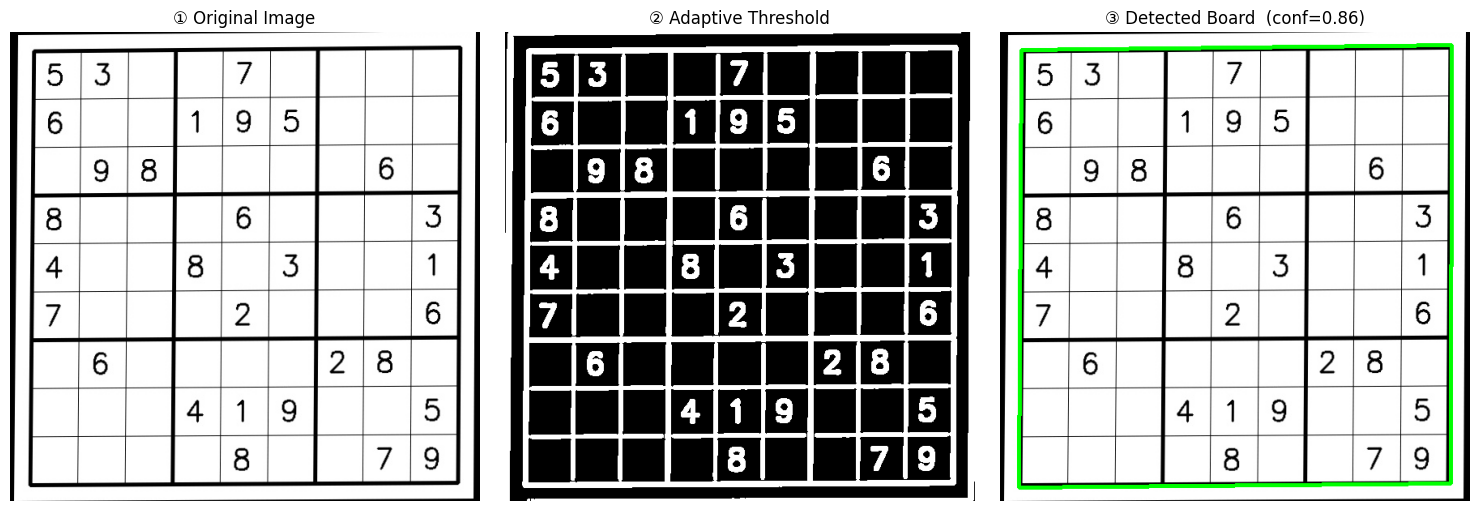

[4/8] Recognising digits...
      ✓ KNN recognition complete  |  51 empty cells

  Detected Puzzle
  ┌───────┬───────┬───────┐
  │ 5 3 . │ . 7 . │ . . . │
  │ 6 . . │ 1 9 5 │ . . . │
  │ . 9 8 │ . . . │ . 6 . │
  ├───────┼───────┼───────┤
  │ 8 . . │ . 6 . │ . . 3 │
  │ 4 . . │ 8 . 3 │ . . 1 │
  │ 7 . . │ . 2 . │ . . 6 │
  ├───────┼───────┼───────┤
  │ . 6 . │ . . . │ 2 8 . │
  │ . . . │ 4 1 9 │ . . 5 │
  │ . . . │ . 8 . │ . 7 9 │
  └───────┴───────┴───────┘
  Filled: 30  |  Empty: 51
[5/8] Saving puzzle to DB...
      ✓ puzzle_id=41
[6/8] Solving puzzle...
      solved ✓  |  valid=True  |  33.3 ms

  Solution
  ┌───────┬───────┬───────┐
  │ 5 3 4 │ 6 7 8 │ 9 1 2 │
  │ 6 7 2 │ 1 9 5 │ 3 4 8 │
  │ 1 9 8 │ 3 4 2 │ 5 6 7 │
  ├───────┼───────┼───────┤
  │ 8 5 9 │ 7 6 1 │ 4 2 3 │
  │ 4 2 6 │ 8 5 3 │ 7 9 1 │
  │ 7 1 3 │ 9 2 4 │ 8 5 6 │
  ├───────┼───────┼───────┤
  │ 9 6 1 │ 5 3 7 │ 2 8 4 │
  │ 2 8 7 │ 4 1 9 │ 6 3 5 │
  │ 3 4 5 │ 2 8 6 │ 1 7 9 │
  └───────┴───────┴───────┘
  Filled: 81  |  E

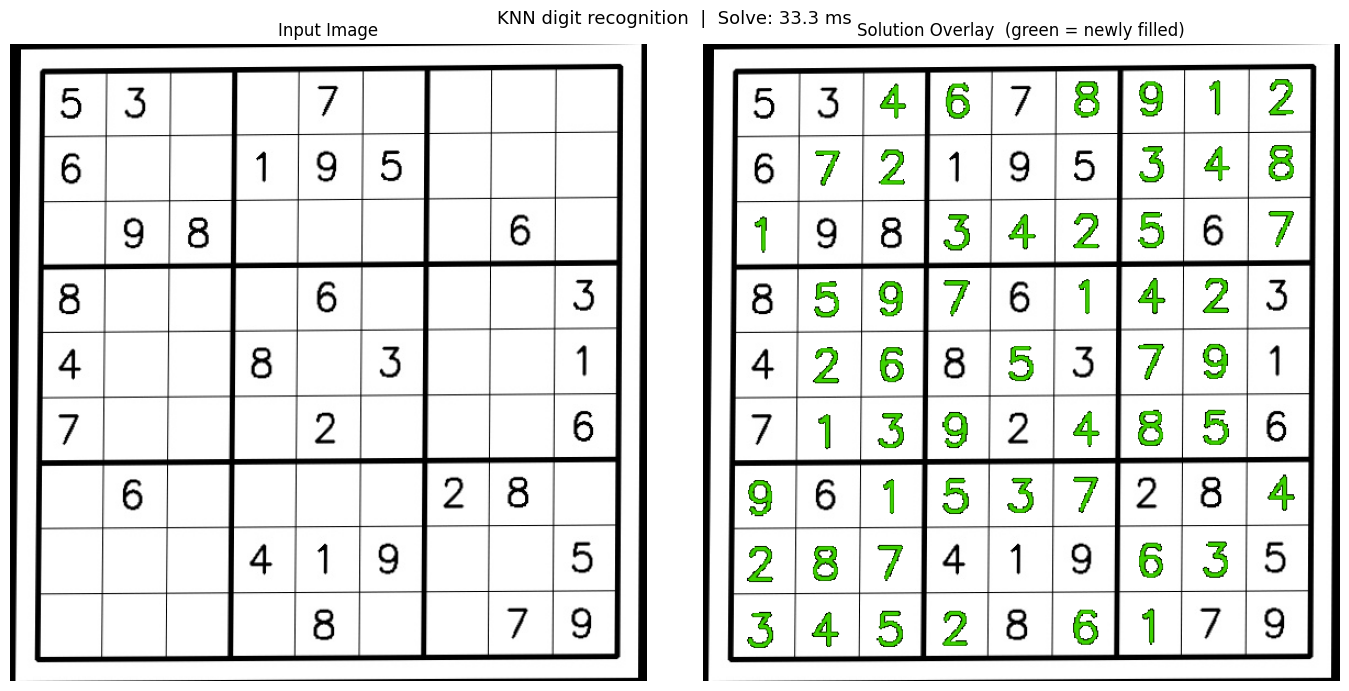


 Pipeline complete in 1432.3 ms


In [49]:
# ─────────────────────────────────────────────────────────────────────────
# CONFIGURE HERE
# ─────────────────────────────────────────────────────────────────────────
IMAGE_PATH = TEST_IMAGE_PATH# ← replace with your photo path
MANUAL_PUZZLE = None              # ← set to a 9×9 list to skip CV recognition
# ─────────────────────────────────────────────────────────────────────────

result = solve_from_image(
    image_path    = IMAGE_PATH,
    manual_puzzle = MANUAL_PUZZLE,
    save_to_db    = True,
    show_steps    = True,
)

## 14. Verify Accuracy of Digit Recognition

In [50]:
# Compare detected puzzle vs ground truth
ground_truth = DEMO_PUZZLE  # change this to your own if using a real image

correct, total = 0, 0
errors = []
for r in range(9):
    for c in range(9):
        if ground_truth[r][c] != 0:
            total += 1
            if result['puzzle'][r][c] == ground_truth[r][c]:
                correct += 1
            else:
                errors.append((r, c, ground_truth[r][c], result['puzzle'][r][c]))

acc = correct / total * 100 if total else 0
print(f'\n Digit Recognition Accuracy: {correct}/{total} = {acc:.1f}%')
if errors:
    print('\n  Misclassified cells:')
    for r, c, expected, got in errors:
        print(f'    ({r},{c})  expected={expected}  got={got}')
else:
    print('  All digits recognised correctly!')
print(f'\n  Solve time : {result["solve_ms"]:.1f} ms')
print(f'  Valid      : {result["is_valid"]}')


 Digit Recognition Accuracy: 30/30 = 100.0%
  All digits recognised correctly!

  Solve time : 33.3 ms
  Valid      : True


## 15. Database Statistics

In [51]:
def show_stats():
    conn  = get_connection()
    stats = conn.execute('''
        SELECT
            COUNT(*)                        AS total_puzzles,
            SUM(s.is_valid)                 AS solved_ok,
            ROUND(AVG(s.solve_time_ms), 2)  AS avg_ms,
            ROUND(MIN(s.solve_time_ms), 2)  AS min_ms,
            ROUND(MAX(s.solve_time_ms), 2)  AS max_ms,
            ROUND(AVG(p.empty_cells), 1)    AS avg_empty
        FROM puzzles p
        LEFT JOIN solutions s ON s.puzzle_id = p.id
    ''').fetchone()
    conn.close()

    print('\n Database Statistics')
    print('─' * 40)
    print(f'  Total puzzles processed : {stats["total_puzzles"]}')
    print(f'  Successfully solved     : {stats["solved_ok"]}')
    print(f'  Average solve time      : {stats["avg_ms"]} ms')
    print(f'  Fastest solve           : {stats["min_ms"]} ms')
    print(f'  Slowest solve           : {stats["max_ms"]} ms')
    print(f'  Avg empty cells / puzzle: {stats["avg_empty"]}')

show_stats()


 Database Statistics
────────────────────────────────────────
  Total puzzles processed : 41
  Successfully solved     : 38
  Average solve time      : 50.29 ms
  Fastest solve           : 19.76 ms
  Slowest solve           : 265.04 ms
  Avg empty cells / puzzle: 54.0


## 16.  Random Puzzle Generator

Run this cell every time to:
1. **Generate** a brand-new random Sudoku puzzle (choose difficulty below)
2. **Display** the unsolved puzzle
3. **Solve** it with the optimised backtracking solver
4. **Display** the solved puzzle
5. **Save** both unsolved + solved to SQLite automatically



    NEW HARD PUZZLE


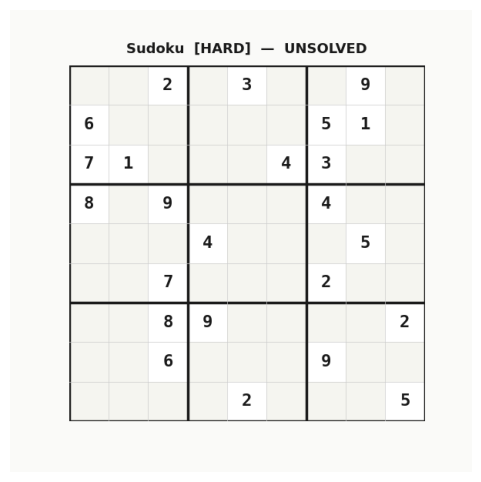

Unsolved saved → puzzles.id = 42


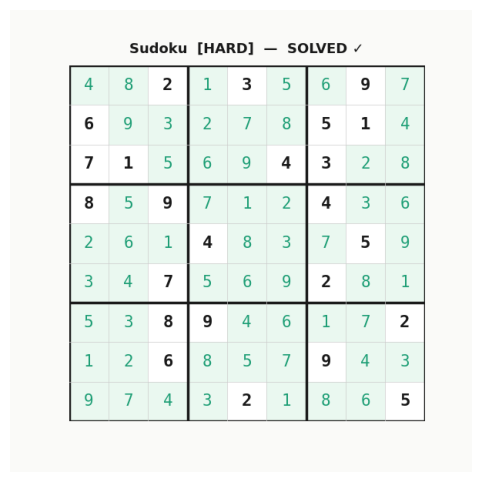

Solution saved → solutions.id = 39
Valid: True | Time: 65.0 ms


 Database Statistics
────────────────────────────────────────
  Total puzzles processed : 42
  Successfully solved     : 39
  Average solve time      : 50.67 ms
  Fastest solve           : 19.76 ms
  Slowest solve           : 265.04 ms
  Avg empty cells / puzzle: 54.1


In [52]:
# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────

DIFFICULTY = "hard"

CLUE_COUNT = {
    "easy": 36,
    "medium": 30,
    "hard": 24
}

# ─────────────────────────────────────────────
# CORE: GRID GENERATION
# ─────────────────────────────────────────────

def _fill_grid(grid):
    """Recursively fill a 9x9 grid with a valid Sudoku solution (randomised)."""
    for row in range(9):
        for col in range(9):
            if grid[row][col] == 0:
                nums = list(range(1, 10))
                random.shuffle(nums)
                for num in nums:
                    g = np.array(grid)
                    box_r = (row // 3) * 3
                    box_c = (col // 3) * 3
                    if (num not in g[row]
                            and num not in g[:, col]
                            and num not in g[box_r:box_r+3, box_c:box_c+3]):
                        grid[row][col] = num
                        if _fill_grid(grid):
                            return True
                        grid[row][col] = 0
                return False
    return True


def generate_puzzle(difficulty="hard"):
    """Generate a random Sudoku puzzle + its full solution."""
    solution = [[0]*9 for _ in range(9)]
    _fill_grid(solution)

    clues_needed    = CLUE_COUNT.get(difficulty, 30)
    cells_to_remove = 81 - clues_needed

    puzzle    = deepcopy(solution)
    positions = list(range(81))
    random.shuffle(positions)

    for pos in positions[:cells_to_remove]:
        r, c = divmod(pos, 9)
        puzzle[r][c] = 0

    return puzzle, solution


# ─────────────────────────────────────────────
# CORE: RENDERING
# ─────────────────────────────────────────────

def render_sudoku_image(puzzle, solved_grid=None, title="Sudoku", difficulty=""):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.axis('off')

    fig.patch.set_facecolor('#FAFAF8')
    ax.set_facecolor('#FAFAF8')

    for r in range(9):
        for c in range(9):
            x, y = c, 8 - r

            val = puzzle[r][c]
            is_given  = val != 0
            is_solved = (solved_grid is not None) and (not is_given)

            bg = '#FFFFFF' if is_given else ('#EAF8F0' if is_solved else '#F5F5F0')
            rect = patches.Rectangle((x, y), 1, 1, linewidth=0, facecolor=bg)
            ax.add_patch(rect)

            display_val = val if is_given else (solved_grid[r][c] if is_solved else '')
            if display_val:
                color      = '#1A1A1A' if is_given else '#1D9E75'
                fontweight = 'bold' if is_given else 'normal'
                fontsize   = 16 if is_given else 15
                ax.text(x + 0.5, y + 0.5, str(display_val),
                        ha='center', va='center',
                        fontsize=fontsize, fontweight=fontweight,
                        color=color, fontfamily='monospace')

    for i in range(10):
        lw    = 2.5 if i % 3 == 0 else 0.5
        color = '#1A1A1A' if i % 3 == 0 else '#CCCCCC'
        ax.plot([i, i], [0, 9], color=color, linewidth=lw)
        ax.plot([0, 9], [i, i], color=color, linewidth=lw)

    status     = 'SOLVED ✓' if solved_grid else 'UNSOLVED'
    diff_label = difficulty.upper() if difficulty else ''
    ax.set_title(f"{title}  [{diff_label}]  —  {status}",
                 fontsize=13, fontweight='bold', pad=12,
                 color='#1A1A1A')

    fig.canvas.draw()
    w, h   = fig.canvas.get_width_height()
    buf    = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    img_rgba = buf.reshape(h, w, 4)
    img_rgb  = img_rgba[:, :, :3]
    img_bgr  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    plt.close(fig)
    return img_bgr


# ─────────────────────────────────────────────
# RUN PIPELINE
# ─────────────────────────────────────────────

def run_random_puzzle(difficulty=DIFFICULTY):

    print(f"\n{'='*55}")
    print(f"    NEW {difficulty.upper()} PUZZLE")
    print(f"{'='*55}")

    puzzle, _ = generate_puzzle(difficulty)

    # ── Show UNSOLVED ──
    img_unsolved = render_sudoku_image(puzzle, None, "Sudoku", difficulty)
    fig_u, ax_u = plt.subplots(figsize=(6, 6))
    ax_u.imshow(cv2.cvtColor(img_unsolved, cv2.COLOR_BGR2RGB))
    ax_u.axis('off')
    plt.show()

    # ── Save puzzle ──
    puzzle_id = save_puzzle(puzzle, source_path=f"generated:{difficulty}")
    print(f"Unsolved saved → puzzles.id = {puzzle_id}")

    # ── Solve ──
    grid_to_solve = deepcopy(puzzle)
    t0 = time.time()
    solved = solve_sudoku(grid_to_solve)
    solve_ms = (time.time() - t0) * 1000

    if not solved:
        print("Solver failed.")
        return None

    is_valid = validate_solution(grid_to_solve)

    # ── Show SOLVED ──
    img_solved = render_sudoku_image(puzzle, grid_to_solve, "Sudoku", difficulty)
    fig_s, ax_s = plt.subplots(figsize=(6, 6))
    ax_s.imshow(cv2.cvtColor(img_solved, cv2.COLOR_BGR2RGB))
    ax_s.axis('off')
    plt.show()

    # ── Save solution ──
    solution_id = save_solution(puzzle_id, grid_to_solve, solve_ms, is_valid)
    save_result_image(solution_id, img_solved)

    print(f"Solution saved → solutions.id = {solution_id}")
    print(f"Valid: {is_valid} | Time: {solve_ms:.1f} ms")

    print()
    show_stats()

    return {
        "puzzle_id": puzzle_id,
        "solution_id": solution_id,
        "is_valid": is_valid,
        "solve_ms": solve_ms
    }


# ─────────────────────────────────────────────
# EXECUTION
# ─────────────────────────────────────────────

result = run_random_puzzle(DIFFICULTY)

## 17. Query the Database

In [53]:
# ── Recent solve history ───────────────────────────────────────────────────
history = fetch_history(limit=10)
print(f"{'ID':<5} {'Source':<30} {'Empty':<7} {'SolveMs':<10} {'Valid':<6} {'Created'}")
print('─' * 78)
for row in history:
    src   = (row['source_path'] or '')[-29:]
    ms    = f"{row['solve_time_ms']:.1f}" if row['solve_time_ms'] is not None else 'N/A'
    valid = '✓' if row['is_valid'] else '✗'
    print(f"{row['id']:<5} {src:<30} {row['empty_cells']:<7} {ms:<10} {valid:<6} {row['created_at'][:19]}")

ID    Source                         Empty   SolveMs    Valid  Created
──────────────────────────────────────────────────────────────────────────────
42    generated:hard                 57      65.0       ✓      2026-05-12T16:39:39
41    test_sudoku.jpg                51      33.3       ✓      2026-05-12T16:39:38
40    generated:hard                 57      67.0       ✓      2026-05-12T16:38:07
39    generated:hard                 57      N/A        ✗      2026-05-12T16:35:05
38    generated:hard                 57      N/A        ✗      2026-05-12T16:34:44
37    generated:hard                 57      N/A        ✗      2026-05-12T16:33:26
36    generated:hard                 57      265.0      ✓      2026-05-12T16:27:27
35    generated:hard                 57      106.2      ✓      2026-05-12T16:26:34
34    test_sudoku.jpg                51      33.9       ✓      2026-05-12T16:26:21
33    generated:mediam               51      23.5       ✓      2026-05-12T16:13:39


## 18. Retrieve Stored Result Image from DB

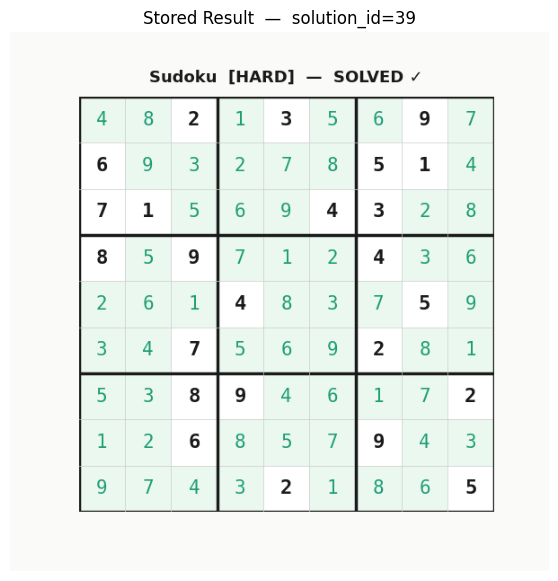

In [54]:
def show_stored_result(solution_id):
    conn = get_connection()
    row  = conn.execute(
        'SELECT image_b64 FROM result_images WHERE solution_id=?', (solution_id,)
    ).fetchone()
    conn.close()
    if row is None:
        print(f'No result image for solution_id={solution_id}')
        return
    img_bytes = base64.b64decode(row['image_b64'])
    buf       = np.frombuffer(img_bytes, np.uint8)
    img       = cv2.imdecode(buf, cv2.IMREAD_COLOR)
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Stored Result  —  solution_id={solution_id}')
    plt.axis('off')
    plt.show()

if result['solution_id']:
    show_stored_result(result['solution_id'])

## 19. Batch Processing

In [55]:
def batch_solve(image_paths, manual_puzzles=None):
    """
    Solve multiple images and store all results in the DB.
    Returns list of result dicts (None for failed images).
    """
    results = []
    for i, path in enumerate(image_paths):
        puzzle = manual_puzzles[i] if manual_puzzles else None
        print(f'\n[{i+1}/{len(image_paths)}] {path}')
        try:
            r = solve_from_image(path, manual_puzzle=puzzle,
                                  save_to_db=True, show_steps=False)
            results.append(r)
            print(f'  → solved={r["is_valid"]}  time={r["solve_ms"]:.1f} ms')
        except Exception as e:
            print(f'  → ERROR: {e}')
            results.append(None)

    ok = sum(1 for r in results if r and r['is_valid'])
    print(f'\n✓ Batch done: {ok}/{len(image_paths)} solved successfully')
    show_stats()
    return results

# Example (uncomment to use):
# batch_solve(['puzzle1.jpg', 'puzzle2.jpg'])
print('✓ batch_solve() ready')

✓ batch_solve() ready


## 20. Project Summary

### Full Pipeline

```
Camera Image
    │
    ▼
Preprocess    →  grayscale  →  Gaussian blur  →  adaptive threshold  →  dilate
    │
    ▼
Board Detection  →  contour detection  →  largest quadrilateral  →  confidence score
    │
    ▼
Perspective Transform  →  reorder 4 corners  →  warpPerspective  →  450×450 flat board
    │
    ▼
Digit Recognition  →  split 81 cells  →  Otsu threshold  →  bounding-box crop
    │                →  resize to 20×20  →  KNN classifier (k=5, distance-weighted)
    ▼
Backtracking Solver  →  Most-Constrained-Variable heuristic  →  validate solution
    │
    ├──▶  SQLite DB  →  puzzles | solutions | detection_logs | result_images
    │
    ▼
Overlay  →  draw digits on flat canvas  →  inverse warpPerspective  →  composite
    │
    ▼
 Display & Query
```

### Database Schema

| Table | Key Columns |
|---|---|
| `puzzles` | id, source_path, grid_json, empty_cells, created_at |
| `solutions` | id, puzzle_id, solution_json, solve_time_ms, is_valid |
| `detection_logs` | id, puzzle_id, board_detected, confidence, corners_json, processing_ms |
| `result_images` | id, solution_id, image_b64 |
